<a href="https://colab.research.google.com/github/SynapTechUMNG/MicroestadosEEG01/blob/main/EEG_Preprocessing_Pipeline_EEGLAB_MNE_Calude_09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Pipeline Completo de Preprocesamiento EEG
## Equivalente a MATLAB + EEGLAB · Implementado en MNE-Python

---

| Paso | Descripción | EEGLAB | MNE-Python |
|------|-------------|--------|------------|
| 1 | Instalación y entorno | — | pip install |
| 2 | Importar datos crudos | `pop_loadset` / `pop_biosig` | `read_raw_*` |
| 3 | Montaje de canales | `pop_chanedit` | `set_montage` |
| 4 | Remuestreo | `pop_resample` | `.resample()` |
| 5 | Filtrado pasa-altas/bajas | `pop_eegfiltnew` | `.filter()` |
| 6 | Filtro Notch | CleanLine plugin | `.notch_filter()` |
| 7 | Re-referenciación | `pop_reref([])` | `set_eeg_reference` |
| 8 | Detección canales malos | `clean_rawdata` | NoisyChannels / z-score |
| 9 | Interpolación esférica | `pop_interp(spherical)` | `interpolate_bads` |
| 10 | ICA — Extended Infomax | `pop_runica` | `ICA(infomax)` |
| 11 | Clasificación ICA | ICLabel plugin | `label_components` |
| 12 | Extracción de épocas | `pop_epoch` | `Epochs()` |
| 13 | Rechazo de épocas | `pop_autorej` | `AutoReject` |
| 14 | Corrección línea base | `pop_rmbase` | `apply_baseline` |
| 15 | Guardar resultados | `pop_saveset` | `.save()` |

> **Cómo usar:** Ejecuta las celdas en orden (Runtime → Run all) o celda por celda con `Shift+Enter`.
> En el **Paso 2** puedes subir tu propio archivo EEG o usar los datos de demo incluidos.

## ⚙️ Paso 1 — Instalación de dependencias

Instala todas las bibliotecas necesarias. Solo se ejecuta una vez por sesión de Colab.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  INSTALACIÓN DE DEPENDENCIAS
#  Tiempo estimado: ~2-3 min en Colab
# ─────────────────────────────────────────────────────────────────────────────
import subprocess, sys

pkgs = [
    "mne>=1.6.0",           # Core EEG/MEG analysis (equivalente a EEGLAB)
    "mne-icalabel>=0.6.0",  # Clasificación automática de componentes ICA (= ICLabel)
    "autoreject>=0.4.3",    # Rechazo automático de épocas (= pop_autorej)
    "pyprep>=0.4.3",        # PREP pipeline: detección RANSAC de canales malos
    "matplotlib>=3.7",
    "numpy>=1.24",
    "scipy>=1.11",
    "pandas>=2.0",
]

print("Instalando paquetes...")
for pkg in pkgs:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", pkg],
        capture_output=True
    )
    print(f"  ✓ {pkg.split('>=')[0]}")

print("\n✅ Instalación completada. Reinicia el kernel si hay errores de importación.")
print("   Runtime → Restart session (solo si hay advertencias de versión)")

Instalando paquetes...
  ✓ mne
  ✓ mne-icalabel
  ✓ autoreject
  ✓ pyprep
  ✓ matplotlib
  ✓ numpy
  ✓ scipy
  ✓ pandas

✅ Instalación completada. Reinicia el kernel si hay errores de importación.
   Runtime → Restart session (solo si hay advertencias de versión)


## 📦 Importaciones y configuración global

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  IMPORTACIONES
# ─────────────────────────────────────────────────────────────────────────────
import os, json, warnings, logging
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from IPython.display import display, Image, HTML, clear_output
import ipywidgets as widgets

import mne
from mne.preprocessing import ICA
from mne import find_events, Epochs

# ── Librerías opcionales ──────────────────────────────────────────────────────
try:
    from mne_icalabel import label_components
    ICALABEL_OK = True
    print("✓ mne-icalabel cargado  (ICLabel equivalente)")
except ImportError:
    ICALABEL_OK = False
    print("⚠ mne-icalabel no disponible — se usará correlación EOG/ECG")

try:
    from autoreject import AutoReject, get_rejection_threshold
    AUTOREJECT_OK = True
    print("✓ autoreject cargado    (pop_autorej equivalente)")
except ImportError:
    AUTOREJECT_OK = False
    print("⚠ autoreject no disponible — se usará umbral fijo")

try:
    from pyprep.find_noisy_channels import NoisyChannels
    PYPREP_OK = True
    print("✓ pyprep cargado        (clean_rawdata RANSAC equivalente)")
except ImportError:
    PYPREP_OK = False
    print("⚠ pyprep no disponible  — se usará detección estadística")

# ── Silenciar logs no críticos ────────────────────────────────────────────────
mne.set_log_level("WARNING")
warnings.filterwarnings("ignore", category=RuntimeWarning)
logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s [%(levelname)s] %(message)s")
logger = logging.getLogger(__name__)

print("\n✅ Entorno listo")

✓ mne-icalabel cargado  (ICLabel equivalente)
✓ autoreject cargado    (pop_autorej equivalente)
✓ pyprep cargado        (clean_rawdata RANSAC equivalente)

✅ Entorno listo


## ⚙️ Configuración del pipeline

Ajusta estos parámetros según tu experimento **antes de ejecutar** el resto del notebook.

| Parámetro clave | Valor típico ERP | Valor típico TF/Bandas |
|-----------------|-----------------|------------------------|
| `highpass_freq` | 0.1 – 1.0 Hz | 1.0 Hz |
| `lowpass_freq` | 30 – 40 Hz | 80 – 100 Hz |
| `notch_freqs` | [50] Europa/LAT · [60] USA | igual |
| `sfreq_target` | 256 Hz | 512 Hz |
| `tmin / tmax` | -0.2 / 0.8 s | -0.5 / 1.5 s |

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  ╔══════════════════════════════════════════════════════╗
#  ║   AJUSTA ESTOS PARÁMETROS SEGÚN TU EXPERIMENTO      ║
#  ╚══════════════════════════════════════════════════════╝
# ─────────────────────────────────────────────────────────────────────────────

CONFIG = {

    # ── Directorios ────────────────────────────────────────────────────────
    "output_dir":            "/content/eeg_output",

    # ── Identificador del sujeto ───────────────────────────────────────────
    "subject_id":            "sub-01",

    # ── Montaje (posiciones de electrodos) ────────────────────────────────
    # Opciones estándar: 'standard_1020' | 'standard_1005' |
    #                    'biosemi64' | 'biosemi128' | 'easycap-M1'
    # Archivo custom:    ruta a .loc / .sfp / .xyz
    "montage":               "standard_1020",

    # ── Canales especiales ────────────────────────────────────────────────
    "eog_channels":          [],        # Ej. ['EOG1','EOG2'] o ['VEOG','HEOG']
    "misc_channels":         [],        # Canales no-EEG a ignorar

    # ── Remuestreo ────────────────────────────────────────────────────────
    "resample":              True,
    "sfreq_target":          256,       # Hz

    # ── Filtrado ──────────────────────────────────────────────────────────
    "highpass_freq":         1.0,       # Hz  (0.1 para ERP de larga latencia)
    "lowpass_freq":          40.0,      # Hz
    "notch_freqs":           [50.0],    # Hz  (60 Hz si grabaste en USA/CAN/JPN)
    "filter_method":         "fir",
    "fir_window":            "hamming",

    # ── Re-referencia ─────────────────────────────────────────────────────
    # 'average' | ['Cz'] | ['M1','M2'] | 'REST'
    "reference":             "average",

    # ── Canales malos ─────────────────────────────────────────────────────
    "detect_bad_channels":   True,
    # 'ransac' (requiere pyprep) | 'statistical' (siempre disponible)
    "bad_channel_method":    "statistical",
    "ransac_threshold":      0.75,
    "interpolate_bads":      True,

    # ── ICA ───────────────────────────────────────────────────────────────
    "run_ica":               True,
    # 'infomax' (= runica EEGLAB) | 'fastica' | 'picard'
    "ica_method":            "infomax",
    "ica_extended":          True,      # Extended Infomax = default EEGLAB
    "ica_max_iter":          800,
    "ica_random_state":      42,
    "ica_n_components":      None,      # None = rank automático

    # ── Rechazo de componentes ICA ────────────────────────────────────────
    "ica_reject_labels":     ["eye blink", "heart beat",
                              "muscle artifact", "channel noise",
                              "line noise"],
    "ica_threshold":         0.80,      # Probabilidad mínima para rechazar

    # ── Épocas ────────────────────────────────────────────────────────────
    "epoch_events":          None,      # None = todos | ['S  1','S  2']
    "tmin":                  -0.2,      # s
    "tmax":                   0.8,      # s
    "baseline":              (-0.2, 0.0),
    "baseline_mode":         "mean",

    # ── Rechazo de épocas ─────────────────────────────────────────────────
    "reject_epochs":         True,
    "peak_to_peak_uV":       None,      # None = AutoReject automático | ej. 100

    # ── Guardado ──────────────────────────────────────────────────────────
    "save_format":           "fif",     # 'fif' | 'set'
    "save_intermediate":     True,      # Checkpoints tras ICA y canales
    "overwrite":             True,
}

# Crear directorio de salida
os.makedirs(CONFIG["output_dir"], exist_ok=True)
print("✅ Configuración aplicada")
print(f"   Sujeto     : {CONFIG['subject_id']}")
print(f"   Filtros    : HP {CONFIG['highpass_freq']} Hz  |  LP {CONFIG['lowpass_freq']} Hz")
print(f"   Notch      : {CONFIG['notch_freqs']} Hz")
print(f"   Referencia : {CONFIG['reference']}")
print(f"   ICA        : {CONFIG['ica_method']} (extended={CONFIG['ica_extended']})")
print(f"   Épocas     : [{CONFIG['tmin']}, {CONFIG['tmax']}] s")
print(f"   Salida     : {CONFIG['output_dir']}")

✅ Configuración aplicada
   Sujeto     : sub-01
   Filtros    : HP 1.0 Hz  |  LP 40.0 Hz
   Notch      : [50.0] Hz
   Referencia : average
   ICA        : infomax (extended=True)
   Épocas     : [-0.2, 0.8] s
   Salida     : /content/eeg_output


## 📂 Paso 2 — Cargar datos EEG

**Opción A:** Sube tu archivo EEG (.set, .edf, .bdf, .vhdr, .fif, .cnt, .gdf)

**Opción B:** Usa los datos de demo de MNE (sample dataset — EEG + MEG 64 canales, 600 Hz)

Ejecuta la celda y elige qué opción usar.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  PASO 2 — CARGA DE DATOS
#  pop_loadset() | pop_biosig() | pop_fileio()  →  mne.io.read_raw_*()
# ─────────────────────────────────────────────────────────────────────────────

USE_DEMO = False   # <── Cambia a False para subir tu propio archivo

if USE_DEMO:
    # ── Opción B: Dataset de demo de MNE ─────────────────────────────────
    print("Descargando datos de demo de MNE (sample dataset)...")
    sample_path = mne.datasets.sample.data_path()
    raw_file    = sample_path / "MEG" / "sample" / "sample_audvis_raw.fif"
    raw = mne.io.read_raw_fif(raw_file, preload=True, verbose=False)

    # Conservar solo canales EEG para el demo
    raw.pick_types(eeg=True, stim=True, eog=True)
    CONFIG["eog_channels"] = ["EOG 061"]
    raw.set_channel_types({"EOG 061": "eog"})
    print(f"  Dataset: MNE sample (auditory/visual paradigm)")

else:
    # ── Opción A: Subir archivo propio ───────────────────────────────────
    from google.colab import files

    print("Selecciona tu archivo EEG (.set | .edf | .bdf | .vhdr | .fif | .cnt):")
    uploaded = files.upload()

    if not uploaded:
        raise FileNotFoundError("No se subió ningún archivo.")

    filename  = list(uploaded.keys())[0]
    filepath  = f"/content/{filename}"
    ext       = Path(filepath).suffix.lower()

    loaders = {
        ".set":  lambda f: mne.io.read_raw_eeglab(f, preload=True, verbose=False),
        ".edf":  lambda f: mne.io.read_raw_edf(f, preload=True, verbose=False),
        ".bdf":  lambda f: mne.io.read_raw_bdf(f, preload=True, verbose=False),
        ".vhdr": lambda f: mne.io.read_raw_brainvision(f, preload=True, verbose=False),
        ".fif":  lambda f: mne.io.read_raw_fif(f, preload=True, verbose=False),
        ".cnt":  lambda f: mne.io.read_raw_cnt(f, preload=True, verbose=False),
        ".gdf":  lambda f: mne.io.read_raw_gdf(f, preload=True, verbose=False),
    }

    if ext not in loaders:
        raise ValueError(f"Formato '{ext}' no soportado.")

    raw = loaders[ext](filepath)
    print(f"  Archivo cargado: {filename}")

    # Marcar canales EOG / MISC definidos en CONFIG
    ch_map = {ch: "eog"  for ch in CONFIG["eog_channels"]  if ch in raw.ch_names}
    ch_map.update({ch: "misc" for ch in CONFIG["misc_channels"] if ch in raw.ch_names})
    if ch_map:
        raw.set_channel_types(ch_map)

# ── Resumen ───────────────────────────────────────────────────────────────────
n_eeg  = len(mne.pick_types(raw.info, eeg=True))
n_eog  = len(mne.pick_types(raw.info, eog=True))
sfreq  = raw.info["sfreq"]
dur_s  = raw.times[-1]

print(f"\n{'─'*50}")
print(f"  Canales EEG  : {n_eeg}")
print(f"  Canales EOG  : {n_eog}")
print(f"  Frecuencia   : {sfreq} Hz")
print(f"  Duración     : {dur_s:.1f} s ({dur_s/60:.1f} min)")
print(f"  Eventos      : {len(raw.annotations)} anotaciones")
print(f"{'─'*50}")
print("✅ Datos cargados en 'raw'")

Selecciona tu archivo EEG (.set | .edf | .bdf | .vhdr | .fif | .cnt):


Saving eeglab_data.set to eeglab_data.set
Saving eeglab_data.fdt to eeglab_data.fdt
  Archivo cargado: eeglab_data.set

──────────────────────────────────────────────────
  Canales EEG  : 32
  Canales EOG  : 0
  Frecuencia   : 128.0 Hz
  Duración     : 238.3 s (4.0 min)
  Eventos      : 154 anotaciones
──────────────────────────────────────────────────
✅ Datos cargados en 'raw'


## 🗺️ Paso 3 — Montaje de canales

`pop_chanedit()` → `raw.set_montage()`

Asigna las posiciones 3D de los electrodos sobre el scalp.

Montaje estándar: standard_1020


/tmp/ipykernel_6679/833944389.py:27: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


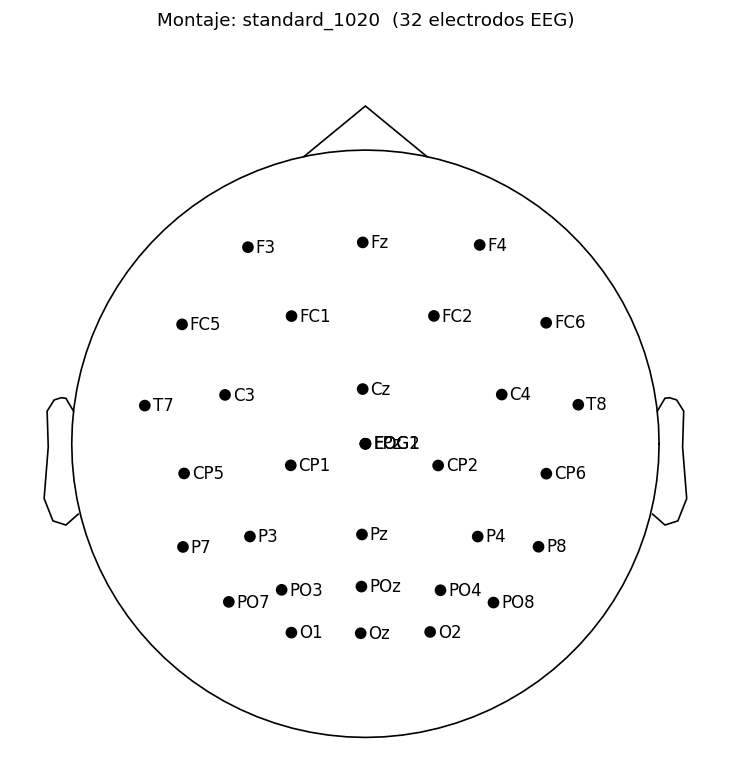


✅ Montaje aplicado — 32 canales EEG con posición 3D


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  PASO 3 — MONTAJE DE CANALES
#  pop_chanedit() | readlocs()  →  set_montage()
# ─────────────────────────────────────────────────────────────────────────────
montage_name = CONFIG["montage"]

if os.path.isfile(str(montage_name)):
    montage = mne.channels.read_custom_montage(montage_name)
    print(f"Montaje personalizado: {montage_name}")
else:
    try:
        montage = mne.channels.make_standard_montage(montage_name)
        print(f"Montaje estándar: {montage_name}")
    except ValueError:
        print(f"⚠ Montaje '{montage_name}' no reconocido — continuando sin montaje")
        montage = None

if montage is not None:
    raw.set_montage(montage, on_missing="ignore", verbose=False)

# ── Gráfica del montaje ───────────────────────────────────────────────────────
eeg_picks = mne.pick_types(raw.info, eeg=True)
if len(eeg_picks) > 0:
    fig = raw.plot_sensors(kind="topomap", show_names=True, show=False)
    fig.suptitle(f"Montaje: {montage_name}  ({len(eeg_picks)} electrodos EEG)",
                 fontsize=11, y=1.01)
    plt.tight_layout()
    out_path = f"{CONFIG['output_dir']}/montaje.png"
    fig.savefig(out_path, dpi=120, bbox_inches="tight")
    plt.close()
    display(Image(out_path))

print(f"\n✅ Montaje aplicado — {len(eeg_picks)} canales EEG con posición 3D")

## 📉 Paso 4 — Remuestreo

`pop_resample(EEG, sfreq)` → `raw.resample(sfreq)`

Reduce la frecuencia de muestreo aplicando un filtro anti-aliasing automático.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  PASO 4 — REMUESTREO
#  pop_resample(EEG, sfreq_target)  →  raw.resample()
# ─────────────────────────────────────────────────────────────────────────────
if CONFIG["resample"]:
    orig_sfreq = raw.info["sfreq"]
    target     = CONFIG["sfreq_target"]

    if orig_sfreq != target:
        print(f"Remuestreando: {orig_sfreq} Hz  →  {target} Hz ...")
        raw.resample(target, npad="auto", verbose=False)
        print(f"✅ Nueva frecuencia de muestreo: {raw.info['sfreq']} Hz")
        print(f"   Muestras por canal: {raw.n_times:,}")
    else:
        print(f"✅ La señal ya está a {target} Hz — sin cambios")
else:
    print(f"Remuestreo desactivado — sfreq actual: {raw.info['sfreq']} Hz")

Remuestreando: 128.0 Hz  →  256 Hz ...
✅ Nueva frecuencia de muestreo: 256.0 Hz
   Muestras por canal: 61,008


## 🔊 Paso 5 — Filtrado pasa-altas / pasa-bajas

`pop_eegfiltnew(EEG, hp, lp)` → `raw.filter(l_freq, h_freq)`

Filtro FIR de **fase cero** (equivalente a `filtfilt` en MATLAB) con ventana de Hamming.
El orden del filtro se calcula automáticamente para garantizar al menos 3 ciclos del período más largo.

Aplicando filtro FIR (Hamming, fase cero)
  Pasa-altas : 1.0 Hz
  Pasa-bajas : 40.0 Hz


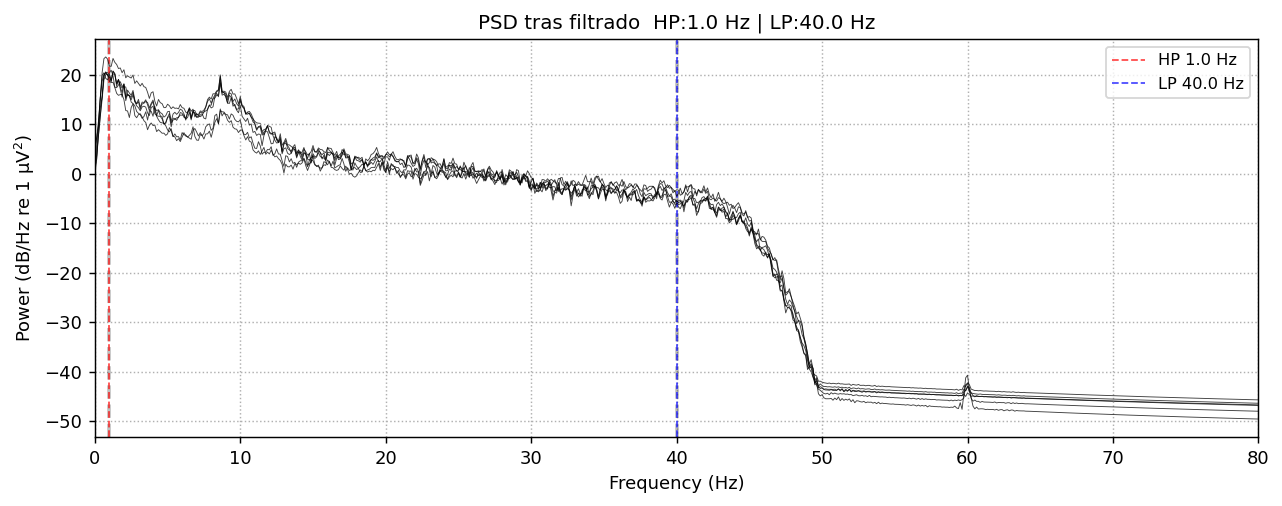


✅ Filtrado completado


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  PASO 5 — FILTRADO PASA-ALTAS Y PASA-BAJAS
#  pop_eegfiltnew(EEG, hp_freq, lp_freq)  →  raw.filter()
# ─────────────────────────────────────────────────────────────────────────────
hp = CONFIG["highpass_freq"]
lp = CONFIG["lowpass_freq"]

eeg_picks = mne.pick_types(raw.info, eeg=True, eog=False, stim=False)

print(f"Aplicando filtro FIR (Hamming, fase cero)")
print(f"  Pasa-altas : {hp} Hz")
print(f"  Pasa-bajas : {lp} Hz")

raw.filter(
    l_freq=hp,
    h_freq=lp,
    picks=eeg_picks,
    method=CONFIG["filter_method"],
    fir_window=CONFIG["fir_window"],
    filter_length="auto",
    phase="zero",
    fir_design="firwin",
    pad="reflect_limited",
    verbose=False,
)

# ── PSD antes y después ───────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 1, figsize=(10, 4))
spectrum = raw.compute_psd(method="welch", fmax=80, picks=eeg_picks[:6],
                            verbose=False)
spectrum.plot(axes=axes, show=False, spatial_colors=False)
axes.set_title(f"PSD tras filtrado  HP:{hp} Hz | LP:{lp} Hz", fontsize=11)
axes.axvline(hp, color="red",   ls="--", lw=1, alpha=0.7, label=f"HP {hp} Hz")
axes.axvline(lp, color="blue",  ls="--", lw=1, alpha=0.7, label=f"LP {lp} Hz")
axes.legend(fontsize=9)
plt.tight_layout()
psd_path = f"{CONFIG['output_dir']}/psd_filtrada.png"
fig.savefig(psd_path, dpi=130, bbox_inches="tight")
plt.close()
display(Image(psd_path))

print("\n✅ Filtrado completado")

## ⚡ Paso 6 — Filtro Notch (línea de potencia)

`CleanLine plugin` / `pop_eegfiltnew(notch)` → `raw.notch_filter()`

Elimina la interferencia de la red eléctrica y sus armónicos. Usa **50 Hz** (Europa/Latinoamérica) o **60 Hz** (USA/Canadá/Japón).

Aplicando Notch en: [50.0, 100.0] Hz


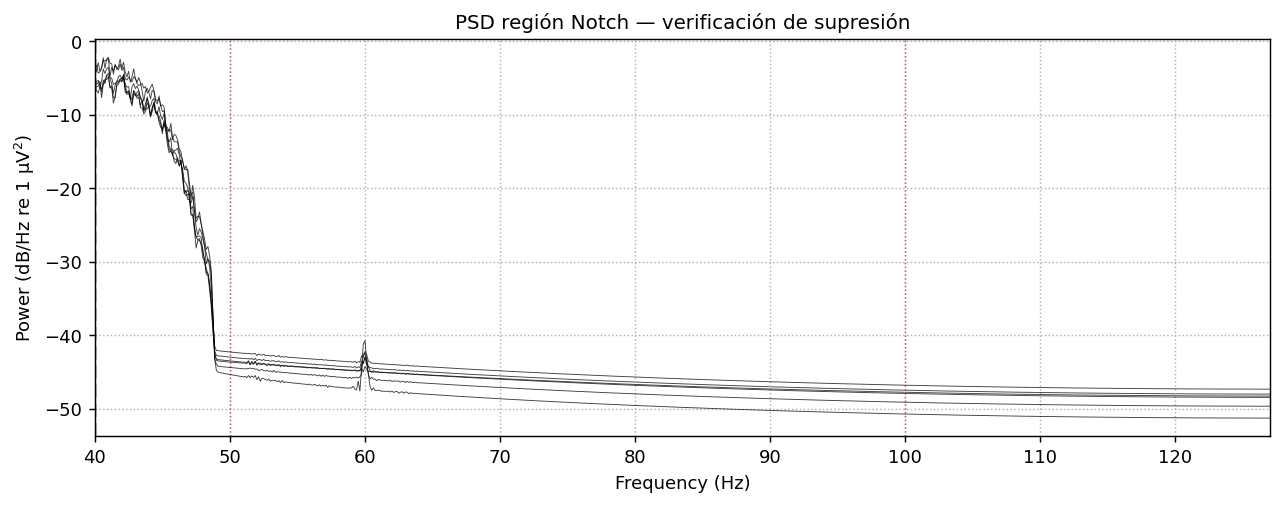


✅ Notch aplicado en [50.0, 100.0] Hz


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  PASO 6 — FILTRO NOTCH
#  CleanLine / pop_eegfiltnew notch  →  raw.notch_filter()
# ─────────────────────────────────────────────────────────────────────────────
notch_freqs = CONFIG["notch_freqs"]
eeg_picks   = mne.pick_types(raw.info, eeg=True, eog=False, stim=False)
sfreq       = raw.info["sfreq"]

# Generar todos los armónicos hasta Nyquist
all_notch = []
for base in notch_freqs:
    h = base
    while h < sfreq / 2:
        all_notch.append(h)
        h += base

print(f"Aplicando Notch en: {all_notch} Hz")

raw.notch_filter(
    freqs=all_notch,
    picks=eeg_picks,
    method="fir",
    notch_widths=2.0,
    phase="zero",
    fir_window="hamming",
    verbose=False,
)

# ── Verificación visual en la banda 45-55 Hz ─────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 4))
spectrum = raw.compute_psd(method="welch", fmin=40, fmax=min(130, sfreq/2 - 1),
                            picks=eeg_picks[:6], verbose=False)
spectrum.plot(axes=ax, show=False, spatial_colors=False)
ax.set_title("PSD región Notch — verificación de supresión", fontsize=11)
for f in all_notch:
    ax.axvline(f, color="red", ls=":", lw=0.8, alpha=0.6)
plt.tight_layout()
notch_path = f"{CONFIG['output_dir']}/psd_notch.png"
fig.savefig(notch_path, dpi=130, bbox_inches="tight")
plt.close()
display(Image(notch_path))

print(f"\n✅ Notch aplicado en {all_notch} Hz")

## 🔁 Paso 7 — Re-referenciación

`pop_reref(EEG, [])` → `raw.set_eeg_reference('average')`

La **referencia promedio** es el estándar en EEGLAB para datos de alta densidad y para el ICA.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  PASO 7 — RE-REFERENCIACIÓN
#  pop_reref(EEG, [])     →  set_eeg_reference('average')
#  pop_reref(EEG, chanN)  →  set_eeg_reference(['Cz'])
# ─────────────────────────────────────────────────────────────────────────────
ref = CONFIG["reference"]
eeg_picks = mne.pick_types(raw.info, eeg=True, eog=False, stim=False)

print(f"Re-referenciando a: '{ref}'")

# Nota: en MNE >= 1.2 set_eeg_reference() ya NO acepta 'picks'.
# Se aplica automáticamente a todos los canales de tipo EEG.
# Si hay canales EOG/STIM, deben estar correctamente tipados (paso 2).

if ref == "average":
    raw.set_eeg_reference(ref_channels="average", projection=False,
                          verbose=False)
elif ref == "REST":
    raw.set_eeg_reference(ref_channels="REST", verbose=False)
elif isinstance(ref, list):
    missing = [ch for ch in ref if ch not in raw.ch_names]
    if missing:
        print(f"  ⚠ Canales no encontrados: {missing}")
        ref = [ch for ch in ref if ch in raw.ch_names]
    if ref:
        raw.set_eeg_reference(ref_channels=ref, verbose=False)
    else:
        print("  ⚠ Sin canales de referencia válidos — usando promedio")
        raw.set_eeg_reference(ref_channels="average", verbose=False)

print(f"✅ Re-referenciación completada → '{ref}'")

Re-referenciando a: 'average'
✅ Re-referenciación completada → 'average'


## 🔴 Paso 8 — Detección de canales malos

`clean_rawdata()` / `pop_rejchan()` → `NoisyChannels()` / detección estadística

**RANSAC** (si `pyprep` está disponible): correlación robusta con vecinos — equivalente exacto a `clean_rawdata` de EEGLAB.

**Estadística** (siempre disponible): z-score del RMS por canal + detección de canales planos.

  ⚠ Canales sin posición 3D válida (excluidos del análisis): ['FPz', 'EOG1', 'EOG2']
Detectando canales malos  (método: statistical)
  Canales EEG válidos para analizar: 29

──────────────────────────────────────────────────
  Canales malos detectados : 0
──────────────────────────────────────────────────


/tmp/ipykernel_6679/3189663483.py:63: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


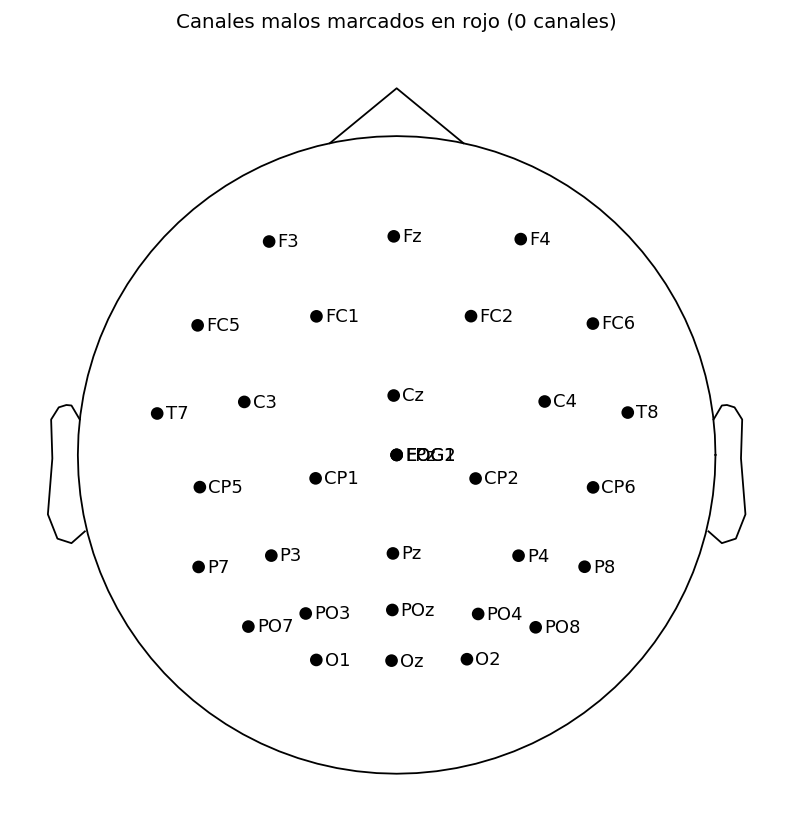


✅ Detección completada


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  PASO 8 — DETECCIÓN DE CANALES MALOS
#  clean_rawdata() / pop_rejchan()  →  NoisyChannels / z-score
# ─────────────────────────────────────────────────────────────────────────────
# Solo canales EEG con posición 3D válida (no NaN) son candidatos
# Excluir EOG/STIM/MISC evita que interpolate_bads falle después
eeg_picks = mne.pick_types(raw.info, eeg=True)

# Filtrar canales sin posición 3D válida (coordenadas NaN → no se pueden interpolar)
valid_eeg_picks = []
for idx in eeg_picks:
    loc = raw.info["chs"][idx]["loc"][:3]
    if np.all(np.isfinite(loc)) and not np.all(loc == 0):
        valid_eeg_picks.append(idx)

invalid_pos = [raw.ch_names[i] for i in eeg_picks if i not in valid_eeg_picks]
if invalid_pos:
    print(f"  ⚠ Canales sin posición 3D válida (excluidos del análisis): {invalid_pos}")

method = CONFIG["bad_channel_method"]
print(f"Detectando canales malos  (método: {method})")
print(f"  Canales EEG válidos para analizar: {len(valid_eeg_picks)}")

if method == "ransac" and PYPREP_OK:
    # ── RANSAC — equivalente exacto a clean_rawdata de EEGLAB ────────────
    print("  Ejecutando RANSAC...")
    nc = NoisyChannels(raw, do_detrend=True, random_state=42)
    nc.find_all_bads(ransac=True)
    # Mantener solo canales EEG con posición válida
    bads = [ch for ch in nc.get_bads() if ch in [raw.ch_names[i] for i in valid_eeg_picks]]
    raw.info["bads"] = bads

else:
    # ── Detección estadística (z-score RMS + canales planos) ─────────────
    # Opera SOLO sobre canales EEG con posición 3D válida
    data_uv      = raw.get_data(picks=valid_eeg_picks) * 1e6   # → µV
    ch_names_eeg = np.array(raw.ch_names)[valid_eeg_picks]

    # Z-score del RMS
    rms     = np.sqrt(np.mean(data_uv ** 2, axis=1))
    mad     = np.median(np.abs(rms - np.median(rms)))
    z_score = (rms - np.median(rms)) / (mad * 1.4826 + 1e-10)
    bad_rms = list(ch_names_eeg[np.abs(z_score) > 3.0])

    # Canales planos (std < 0.5 µV)
    stds     = np.std(data_uv, axis=1)
    bad_flat = list(ch_names_eeg[stds < 0.5])

    bads = list(set(bad_rms + bad_flat))
    raw.info["bads"] = bads

n_bad = len(raw.info["bads"])
print(f"\n{'─'*50}")
print(f"  Canales malos detectados : {n_bad}")
if n_bad > 0:
    print(f"  Canales                  : {raw.info['bads']}")
print(f"{'─'*50}")

# ── Topomap con canales malos marcados ────────────────────────────────────────
if len(eeg_picks) > 0:
    fig = raw.plot_sensors(show_names=True, show=False)
    fig.suptitle(f"Canales malos marcados en rojo ({n_bad} canales)", fontsize=11)
    plt.tight_layout()
    bch_path = f"{CONFIG['output_dir']}/bad_channels.png"
    fig.savefig(bch_path, dpi=130, bbox_inches="tight")
    plt.close()
    display(Image(bch_path))

bad_channels_list = list(raw.info["bads"])  # Guardar para el reporte
print(f"\n✅ Detección completada")

# ── Opción: Añadir canales malos manualmente ─────────────────────────────────
# Descomenta y modifica si detectas visualmente canales adicionales:
# raw.info["bads"] += ["TP9", "FT10"]
# print(f"Canales malos actualizados: {raw.info['bads']}")

## 🔵 Paso 9 — Interpolación esférica

`pop_interp(EEG, badChannels, 'spherical')` → `raw.interpolate_bads()`

Reconstruye los canales malos usando la actividad de los electrodos vecinos.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  PASO 9 — INTERPOLACIÓN ESFÉRICA
#  pop_interp(EEG, bads, 'spherical')  →  raw.interpolate_bads()
# ─────────────────────────────────────────────────────────────────────────────
n_bad = len(raw.info["bads"])

if CONFIG["interpolate_bads"] and n_bad > 0:
    # Guardia de seguridad: solo interpolar canales EEG con posición 3D válida
    # Canales EOG, STIM, MISC o sin posición deben salir de la lista de bads
    eeg_ch_names = set(np.array(raw.ch_names)[mne.pick_types(raw.info, eeg=True)])
    safe_bads = []
    skipped   = []
    for ch in raw.info["bads"]:
        if ch not in eeg_ch_names:
            skipped.append(ch)
            continue
        idx = raw.ch_names.index(ch)
        loc = raw.info["chs"][idx]["loc"][:3]
        if np.all(np.isfinite(loc)) and not np.all(loc == 0):
            safe_bads.append(ch)
        else:
            skipped.append(ch)

    if skipped:
        print(f"  ⚠ Canales omitidos (no-EEG o sin posición válida): {skipped}")

    raw.info["bads"] = safe_bads
    n_safe = len(safe_bads)

    if n_safe > 0:
        print(f"Interpolando {n_safe} canales: {safe_bads}")
        raw.interpolate_bads(
            reset_bads=True,           # Limpiar lista de bads tras interpolar
            mode="accurate",
            origin=(0.0, 0.0, 0.04),   # Centro aproximado de la esfera craneal
            verbose=False,
        )
        print(f"✅ Interpolación esférica completada — {n_safe} canales reconstruidos")
    else:
        print("✅ Sin canales EEG válidos para interpolar tras filtrado de seguridad")

elif n_bad == 0:
    print("✅ Sin canales malos — interpolación no necesaria")
else:
    print("Interpolación desactivada en CONFIG['interpolate_bads']")

if CONFIG["save_intermediate"]:
    path_chk = f"{CONFIG['output_dir']}/{CONFIG['subject_id']}_post_interp_raw.fif"
    raw.save(path_chk, overwrite=CONFIG["overwrite"], verbose=False)
    print(f"   Checkpoint guardado: {path_chk}")

✅ Sin canales malos — interpolación no necesaria
   Checkpoint guardado: /content/eeg_output/sub-01_post_interp_raw.fif


## 🌀 Paso 10 — ICA (Análisis de Componentes Independientes)

`pop_runica(EEG, 'icatype','runica','extended',1)` → `ICA(method='infomax', fit_params={'extended': True})`

**¿Por qué Extended Infomax?** Es el algoritmo por defecto de EEGLAB (`runica`). El modo extendido maneja tanto distribuciones super- como sub-gaussianas, capturando mejor los artefactos de línea (sub-gaussianos).

⏱️ *Este paso puede tardar 2-5 minutos en Colab con GPU.*

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  PASO 10 — ICA
#  pop_runica(EEG,'icatype','runica','extended',1)
#    →  ICA(method='infomax', fit_params={'extended':True})
# ─────────────────────────────────────────────────────────────────────────────
eeg_picks = mne.pick_types(raw.info, eeg=True, eog=False, stim=False)

# ── Calcular el rank efectivo ─────────────────────────────────────────────────
# MNE >= 1.6: compute_rank() ya no acepta 'picks' → copia EEG-only
raw_eeg_only = raw.copy().pick('eeg')
rank         = mne.compute_rank(raw_eeg_only, verbose=False)
rank_val     = list(rank.values())[0]
del raw_eeg_only
n_comps   = CONFIG["ica_n_components"] or (rank_val - 1)
n_comps   = min(n_comps, rank_val - 1)

print(f"ICA — Configuración:")
print(f"  Método      : {CONFIG['ica_method']} (extended={CONFIG['ica_extended']})")
print(f"  Rank datos  : {rank_val}")
print(f"  Componentes : {n_comps}")
print(f"  Max iter    : {CONFIG['ica_max_iter']}")
print("\nEntrenando ICA (puede tardar varios minutos)...")

# ── Crear y ajustar el ICA ────────────────────────────────────────────────────
ica = ICA(
    n_components=n_comps,
    method=CONFIG["ica_method"],
    fit_params={"extended": CONFIG["ica_extended"]},
    max_iter=CONFIG["ica_max_iter"],
    random_state=CONFIG["ica_random_state"],
    verbose=False,
)

# Ajustar sobre copia filtrada a 1 Hz (práctica recomendada por EEGLAB)
raw_for_ica = raw.copy().filter(
    l_freq=1.0, h_freq=None,
    picks=eeg_picks,
    method="fir", phase="zero",
    verbose=False,
)

ica.fit(raw_for_ica, picks=eeg_picks, verbose=False)
del raw_for_ica

print(f"\n✅ ICA convergido en {ica.n_iter_} iteraciones")
print(f"   Varianza explicada: {ica.pca_explained_variance_[:n_comps].sum():.1%}")

# ── Guardar pesos ICA ─────────────────────────────────────────────────────────
ica_path = f"{CONFIG['output_dir']}/{CONFIG['subject_id']}_ica.fif"
ica.save(ica_path, overwrite=CONFIG["overwrite"], verbose=False)
print(f"   ICA guardado: {ica_path}")

# ── Gráfica de topomapas ICA ──────────────────────────────────────────────────
# Construir un raw auxiliar con SOLO canales EEG de posición única y válida.
# Esto evita el ValueError 'overlapping positions' para FPz, EOG1, EOG2, etc.
def _build_plot_inst(raw_src):
    """Devuelve copia de raw con únicamente canales EEG con posición 3D
    finita, no nula y sin solapamiento — apto para plot_components."""
    eeg_idx = mne.pick_types(raw_src.info, eeg=True)
    seen_pos, keep = set(), []
    for idx in eeg_idx:
        loc = tuple(np.round(raw_src.info['chs'][idx]['loc'][:3], 4))
        if (np.all(np.isfinite(raw_src.info['chs'][idx]['loc'][:3]))
                and not np.all(raw_src.info['chs'][idx]['loc'][:3] == 0)
                and loc not in seen_pos):
            keep.append(raw_src.ch_names[idx])
            seen_pos.add(loc)
    return raw_src.copy().pick(keep)

n_show   = min(20, ica.n_components_)
plot_raw = _build_plot_inst(raw)
excluded_from_plot = [ch for ch in raw.ch_names
                      if mne.channel_type(raw.info,
                         raw.ch_names.index(ch)) == 'eeg'
                      and ch not in plot_raw.ch_names]
if excluded_from_plot:
    print(f"  ⚠ Canales excluidos del topomap (posición solapada/inválida): "
          f"{excluded_from_plot}")

try:
    figs = ica.plot_components(picks=range(n_show), inst=plot_raw, show=False)
    figs = figs if isinstance(figs, list) else [figs]
    for i, fig in enumerate(figs):
        topo_path = f"{CONFIG['output_dir']}/ica_topomaps_{i}.png"
        fig.savefig(topo_path, dpi=110, bbox_inches="tight")
        plt.close(fig)
        display(Image(topo_path))
    print(f"\nTopomapas mostrados — identifica componentes de artefactos visualmente")
except Exception as e:
    print(f"  ⚠ No se pudieron graficar los topomapas ICA: {e}")
    print("    El ICA fue calculado correctamente — continúa con el Paso 11.")
finally:
    del plot_raw

ICA — Configuración:
  Método      : infomax (extended=True)
  Rank datos  : 31
  Componentes : 30
  Max iter    : 800

Entrenando ICA (puede tardar varios minutos)...

✅ ICA convergido en 800 iteraciones
   Varianza explicada: 3199.5%
   ICA guardado: /content/eeg_output/sub-01_ica.fif
  ⚠ Canales excluidos del topomap (posición solapada/inválida): ['FPz', 'EOG1', 'EOG2']
  ⚠ No se pudieron graficar los topomapas ICA: The following electrodes have overlapping positions, which causes problems during visualization:
FPz, EOG1, EOG2
    El ICA fue calculado correctamente — continúa con el Paso 11.


## 🏷️ Paso 11 — Clasificación y rechazo de componentes ICA

`ICLabel plugin` / `pop_icflag()` / `pop_subcomp()` → `label_components()` / `ica.apply()`

**Clases de ICLabel:**
- 🧠 `brain` → señal cerebral — **CONSERVAR**
- 👁️ `eye blink` → parpadeo — **RECHAZAR**
- ❤️ `heart beat` → pulso cardíaco — **RECHAZAR**
- 💪 `muscle artifact` → EMG — **RECHAZAR**
- ⚡ `line noise` → ruido eléctrico — **RECHAZAR**
- 📡 `channel noise` → ruido de canal — **RECHAZAR**

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  PASO 11 — CLASIFICACIÓN ICA (ICLabel) + RECHAZO
#  ICLabel / pop_icflag() / pop_subcomp()
#    →  label_components() + ica.apply()
# ─────────────────────────────────────────────────────────────────────────────
reject_labels = CONFIG["ica_reject_labels"]
threshold     = CONFIG["ica_threshold"]
excluded      = []

print("Clasificando componentes ICA...")
print(f"  Etiquetas a rechazar : {reject_labels}")
print(f"  Umbral de probabilidad: {threshold}\n")

if ICALABEL_OK:
    # ── Método 1: mne-icalabel (equivalente exacto a ICLabel de EEGLAB) ───
    # label_components requiere que TODOS los canales EEG tengan posición 3D
    # válida. Usamos _build_plot_inst() para obtener una copia limpia.
    raw_iclabel = _build_plot_inst(raw)
    removed_iclabel = [ch for ch in raw.ch_names
                       if mne.channel_type(raw.info,
                          raw.ch_names.index(ch)) == 'eeg'
                       and ch not in raw_iclabel.ch_names]
    if removed_iclabel:
        print(f"  ⚠ Canales EEG sin posición válida excluidos de ICLabel: "
              f"{removed_iclabel}")
        print("    (el ICA y el rechazo de componentes NO se ven afectados)")

    try:
        ic_labels  = label_components(raw_iclabel, ica, method="iclabel")
        labels_arr = ic_labels["labels"]
        proba_arr  = ic_labels["y_pred_proba"]

        # Tabla de resultados
        rows = []
        for idx, (label, proba) in enumerate(zip(labels_arr, proba_arr)):
            max_prob = float(np.max(proba))
            reject   = label in reject_labels and max_prob >= threshold
            if reject:
                excluded.append(idx)
            rows.append({
                "Componente": idx,
                "Etiqueta": label,
                "Prob.": f"{max_prob:.2f}",
                "Acción": "❌ RECHAZAR" if reject else "✅ CONSERVAR"
            })

        df = pd.DataFrame(rows)
        print(df.to_string(index=False))
        print(f"\nTotal rechazados: {len(excluded)} / {ica.n_components_}")

    except Exception as e:
        print(f"  ⚠ ICLabel falló: {e}")
        print("  Cambiando automáticamente a correlación EOG/ECG...")
        ICALABEL_OK = False   # forzar fallback en este dataset
    finally:
        del raw_iclabel

if not ICALABEL_OK:
    # ── Método 2: correlación con EOG/ECG ────────────────────────────────
    # Activo cuando ICLabel no está instalado O cuando falló en este dataset
    print("Usando correlación con señales EOG/ECG")

    eog_chs = CONFIG["eog_channels"] or [
        ch for ch in raw.ch_names
        if any(k in ch.upper() for k in ["EOG","VEOG","HEOG"])
    ]
    if eog_chs:
        valid_eog = [ch for ch in eog_chs if ch in raw.ch_names]
        if valid_eog:
            eog_idx, _ = ica.find_bads_eog(raw, ch_name=valid_eog[:2],
                                            threshold=3.5, verbose=False)
            excluded.extend(eog_idx)
            print(f"  Componentes EOG: {eog_idx}")

    ecg_chs = [ch for ch in raw.ch_names
               if any(k in ch.upper() for k in ["ECG","EKG","HEART"])]
    if ecg_chs:
        ecg_idx, _ = ica.find_bads_ecg(raw, ch_name=ecg_chs[0],
                                        method="correlation",
                                        threshold=0.25, verbose=False)
        excluded.extend(ecg_idx)
        print(f"  Componentes ECG: {ecg_idx}")

    excluded = list(set(excluded))
    print(f"\nTotal rechazados: {len(excluded)} componentes")

# ── Gráfica de componentes rechazados ─────────────────────────────────────────
if excluded:
    try:
        plot_raw_ex = _build_plot_inst(raw)
        figs_ex = ica.plot_components(
            picks=excluded[:min(8, len(excluded))],
            inst=plot_raw_ex, show=False)
        figs_ex = figs_ex if isinstance(figs_ex, list) else [figs_ex]
        for i, fig in enumerate(figs_ex):
            fig.suptitle(f"Componentes a RECHAZAR — {excluded[:8]}",
                         fontsize=10)
            exc_path = f"{CONFIG['output_dir']}/ica_rechazados_{i}.png"
            fig.savefig(exc_path, dpi=110, bbox_inches="tight")
            plt.close(fig)
            display(Image(exc_path))
        del plot_raw_ex
    except Exception as e:
        print(f"  ⚠ Topomapa de rechazados no disponible: {e}")

# ── AJUSTE MANUAL OPCIONAL ────────────────────────────────────────────────────
# Si quieres añadir o quitar componentes tras revisar los topomapas:
# excluded += [5, 12]   # Añadir componentes
# excluded = [x for x in excluded if x != 3]  # Quitar un componente

# ── Aplicar ICA (equivalente a pop_subcomp) ───────────────────────────────────
ica.exclude = list(set(excluded))
ica.apply(raw, verbose=False)

print(f"\n✅ ICA aplicado — {len(ica.exclude)} componentes de artefacto eliminados")

Clasificando componentes ICA...
  Etiquetas a rechazar : ['eye blink', 'heart beat', 'muscle artifact', 'channel noise', 'line noise']
  Umbral de probabilidad: 0.8

  ⚠ Canales EEG sin posición válida excluidos de ICLabel: ['FPz', 'EOG1', 'EOG2']
    (el ICA y el rechazo de componentes NO se ven afectados)
  ⚠ ICLabel falló: Channel(s) [np.str_('FPz'), np.str_('EOG1'), np.str_('EOG2')] could not be picked, because they are not present in the info instance.
  Cambiando automáticamente a correlación EOG/ECG...
Usando correlación con señales EOG/ECG
  Componentes EOG: [np.int64(1)]

Total rechazados: 1 componentes
  ⚠ Topomapa de rechazados no disponible: The following electrodes have overlapping positions, which causes problems during visualization:
FPz, EOG1, EOG2

✅ ICA aplicado — 1 componentes de artefacto eliminados


## ⏱️ Paso 12 — Extracción de épocas

`pop_epoch(EEG, events, [tmin, tmax])` → `mne.Epochs()`

Segmenta el registro continuo en ventanas temporales ancladas a los eventos/marcadores del experimento.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  PASO 12 — EXTRACCIÓN DE ÉPOCAS
#  pop_epoch(EEG, eventTypes, [tmin tmax])  →  mne.Epochs()
# ─────────────────────────────────────────────────────────────────────────────
tmin   = CONFIG["tmin"]
tmax   = CONFIG["tmax"]

print(f"Extrayendo épocas: [{tmin}, {tmax}] s")

# ── Detectar eventos desde anotaciones ───────────────────────────────────────
try:
    events, event_id = mne.events_from_annotations(raw, verbose=False)
    print(f"  Eventos encontrados: {dict(list(event_id.items())[:6])}")
except Exception:
    events   = None
    event_id = {}

epoch_events_cfg = CONFIG["epoch_events"]

if events is not None and len(events) > 0:
    if epoch_events_cfg:
        event_id = {k: v for k, v in event_id.items()
                    if k in epoch_events_cfg}

    if not event_id:
        _, event_id = mne.events_from_annotations(raw, verbose=False)

    epochs = Epochs(
        raw,
        events=events,
        event_id=event_id,
        tmin=tmin,
        tmax=tmax,
        baseline=None,           # Se aplica en paso 14
        preload=True,
        reject=None,
        flat={"eeg": 1e-6},      # Detectar épocas planas (< 1 µV)
        on_missing="warn",
        verbose=False,
    )

else:
    # Sin eventos: épocas de longitud fija (eeg_regepochs)
    print("  ⚠ Sin eventos — creando épocas de longitud fija")
    dur = tmax - tmin
    events_fixed = mne.make_fixed_length_events(raw, duration=dur, id=1)
    epochs = Epochs(raw, events=events_fixed, event_id={"epoch": 1},
                    tmin=0.0, tmax=dur, baseline=None,
                    preload=True, verbose=False)

n_ep = len(epochs)
print(f"\n✅ {n_ep} épocas extraídas")
print(f"   Tipos de eventos : {list(epochs.event_id.keys())}")
print(f"   Canales EEG      : {len(mne.pick_types(epochs.info, eeg=True))}")
print(f"   Tamaño tensor    : {epochs.get_data().shape}  (épocas × canales × muestras)")

Extrayendo épocas: [-0.2, 0.8] s
  Eventos encontrados: {np.str_('rt'): 1, np.str_('square'): 2}

✅ 154 épocas extraídas
   Tipos de eventos : [np.str_('rt'), np.str_('square')]
   Canales EEG      : 32
   Tamaño tensor    : (154, 32, 257)  (épocas × canales × muestras)


## 🗑️ Paso 13 — Rechazo automático de épocas

`pop_autorej()` / `pop_jointprob()` → `AutoReject()` / umbral pico a pico

**AutoReject** aprende el umbral óptimo por canal usando validación cruzada — equivalente al rechazo adaptativo de EEGLAB.
Se puede usar un umbral fijo en µV si `autoreject` no está disponible.

  ⚠ Canales EEG sin posición válida (excluidos del rechazo): ['FPz', 'EOG1', 'EOG2']
Ejecutando AutoReject (umbrales adaptativos por canal)...
  (puede tardar 1-3 minutos)



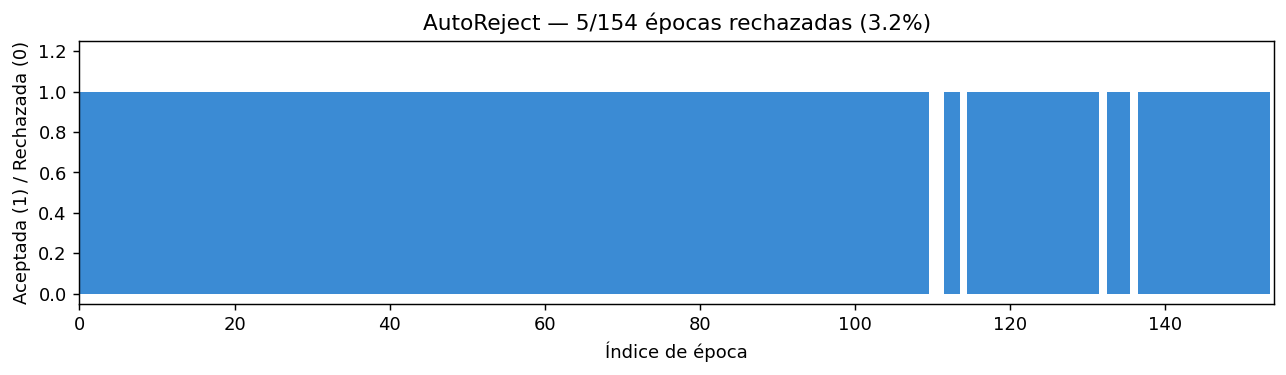


──────────────────────────────────────────────────
  Épocas antes    : 154
  Épocas después  : 149
  Rechazadas      : 5 (3.2%)
──────────────────────────────────────────────────

✅ Rechazo de épocas completado


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  PASO 13 — RECHAZO DE ÉPOCAS
#  pop_autorej() / pop_jointprob()  →  AutoReject / drop_bad()
# ─────────────────────────────────────────────────────────────────────────────
n_before   = len(epochs)
peak_thresh = CONFIG["peak_to_peak_uV"]

# ── Helper: picks con posición 3D válida en epochs ───────────────────────────
def _valid_eeg_picks_epochs(ep):
    """Índices de canales EEG con posición 3D finita, no nula y única."""
    eeg_idx = mne.pick_types(ep.info, eeg=True)
    seen, keep = set(), []
    for idx in eeg_idx:
        loc = ep.info["chs"][idx]["loc"][:3]
        key = tuple(np.round(loc, 4))
        if np.all(np.isfinite(loc)) and not np.all(loc == 0) and key not in seen:
            keep.append(idx); seen.add(key)
    return keep

valid_picks = _valid_eeg_picks_epochs(epochs)
invalid_chs = [epochs.ch_names[i] for i in mne.pick_types(epochs.info, eeg=True)
               if i not in valid_picks]
if invalid_chs:
    print(f"  ⚠ Canales EEG sin posición válida (excluidos del rechazo): {invalid_chs}")

if AUTOREJECT_OK and peak_thresh is None:
    # ── AutoReject — método óptimo ────────────────────────────────────────
    print("Ejecutando AutoReject (umbrales adaptativos por canal)...")
    print("  (puede tardar 1-3 minutos)\n")

    ar = AutoReject(
        n_interpolate=np.array([1, 4, 8]),
        picks=valid_picks,          # Solo canales con posición 3D válida
        random_state=42,
        n_jobs=1,
        verbose=False,
    )
    epochs, reject_log = ar.fit_transform(epochs, return_log=True)
    n_rejected = n_before - len(epochs)

    # Visualizar patrón de rechazo
    fig, ax = plt.subplots(figsize=(10, 3))
    bad_mask = reject_log.bad_epochs.astype(float)
    ax.bar(range(n_before), 1 - bad_mask,
           color=["#3B8BD4" if not b else "#D85A30"
                  for b in reject_log.bad_epochs],
           width=1.0, linewidth=0)
    ax.set_xlabel("Índice de época")
    ax.set_ylabel("Aceptada (1) / Rechazada (0)")
    ax.set_title(f"AutoReject — {n_rejected}/{n_before} épocas rechazadas ({n_rejected/n_before*100:.1f}%)")
    ax.set_ylim(-0.05, 1.25)
    ax.set_xlim(0, n_before)
    plt.tight_layout()
    ar_path = f"{CONFIG['output_dir']}/autoreject_log.png"
    fig.savefig(ar_path, dpi=130, bbox_inches="tight")
    plt.close()
    display(Image(ar_path))

else:
    # ── Umbral fijo pico a pico ───────────────────────────────────────────
    thresh_uV = peak_thresh if peak_thresh else 100.0
    print(f"Rechazo por umbral pico a pico: ±{thresh_uV} µV")
    reject_dict = {"eeg": thresh_uV * 1e-6}
    epochs.drop_bad(reject=reject_dict, verbose=False)  # drop_bad no requiere posición
    n_rejected = n_before - len(epochs)

n_after  = len(epochs)
pct_rej  = n_rejected / n_before * 100

print(f"\n{'─'*50}")
print(f"  Épocas antes    : {n_before}")
print(f"  Épocas después  : {n_after}")
print(f"  Rechazadas      : {n_rejected} ({pct_rej:.1f}%)")
print(f"{'─'*50}")

if pct_rej > 30:
    print("  ⚠ Alto porcentaje de rechazo. Revisa los pasos anteriores.")

print("\n✅ Rechazo de épocas completado")

## 📏 Paso 14 — Corrección de línea base

`pop_rmbase(EEG, [tmin tmax])` → `epochs.apply_baseline()`

Sustrae la media de la ventana pre-estímulo de toda la época. Estabiliza el nivel DC y permite comparar amplitudes entre épocas.

Aplicando corrección de línea base  (-0.2, 0.0) s  (modo: mean)


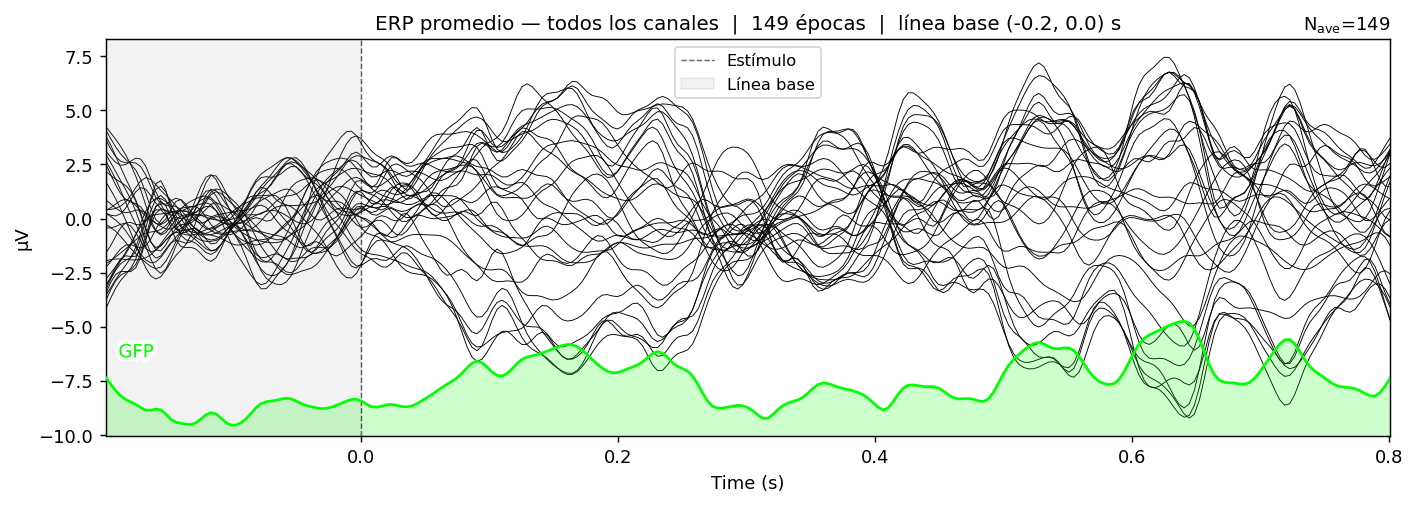


✅ Corrección de línea base aplicada


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  PASO 14 — CORRECCIÓN DE LÍNEA BASE
#  pop_rmbase(EEG, [tmin tmax])  →  epochs.apply_baseline()
# ─────────────────────────────────────────────────────────────────────────────
baseline = CONFIG["baseline"]
print(f"Aplicando corrección de línea base  {baseline} s  (modo: {CONFIG['baseline_mode']})")

epochs.apply_baseline(baseline=baseline, verbose=False)

# ── Gráfica ERP global para verificar ────────────────────────────────────────
# Recomputar valid_ep DESPUÉS del rechazo de épocas (AutoReject puede haber
# cambiado el nº de canales). Usar nombres de canal en lugar de índices para
# que sean válidos tanto en epochs como en evoked.
valid_ep      = _valid_eeg_picks_epochs(epochs)
valid_ep_names = [epochs.ch_names[i] for i in valid_ep]
evoked        = epochs.average(picks=valid_ep)

fig, ax = plt.subplots(figsize=(11, 4))
evoked.plot(axes=ax, show=False, spatial_colors=False, gfp=True,
            picks=valid_ep_names)
ax.set_title(f"ERP promedio — todos los canales  |  {len(epochs)} épocas  |  línea base {baseline} s",
             fontsize=11)
ax.axvline(0, color="black", ls="--", lw=0.8, alpha=0.6, label="Estímulo")
ax.axvspan(baseline[0], baseline[1], color="gray", alpha=0.1, label="Línea base")
ax.legend(fontsize=9)
plt.tight_layout()
erp_path = f"{CONFIG['output_dir']}/erp_global.png"
fig.savefig(erp_path, dpi=130, bbox_inches="tight")
plt.close()
display(Image(erp_path))

print("\n✅ Corrección de línea base aplicada")

## 💾 Paso 15 — Guardar resultados

`pop_saveset(EEG, 'filename', ...)` → `epochs.save()` + `raw.save()`

Guarda los datos preprocesados en formato `.fif` (nativo MNE) o `.set` (compatible con EEGLAB/MATLAB).

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  PASO 15 — GUARDAR RESULTADOS
#  pop_saveset(EEG, ...)  →  epochs.save() / raw.save()
# ─────────────────────────────────────────────────────────────────────────────
out   = CONFIG["output_dir"]
sid   = CONFIG["subject_id"]
fmt   = CONFIG["save_format"]
ow    = CONFIG["overwrite"]

saved_files = []

# ── Épocas preprocesadas ──────────────────────────────────────────────────────
if fmt == "set":
    ep_path = f"{out}/{sid}_preprocessed-epo.set"
    epochs.export(ep_path, fmt="eeglab", overwrite=ow, verbose=False)
else:
    ep_path = f"{out}/{sid}_preprocessed-epo.fif"
    epochs.save(ep_path, overwrite=ow, verbose=False)
saved_files.append(ep_path)

# ── Raw continuo preprocesado ─────────────────────────────────────────────────
raw_path = f"{out}/{sid}_preprocessed_raw.fif"
raw.save(raw_path, overwrite=ow, verbose=False)
saved_files.append(raw_path)

# ── ICA final ─────────────────────────────────────────────────────────────────
ica_final = f"{out}/{sid}_final-ica.fif"
ica.save(ica_final, overwrite=ow, verbose=False)
saved_files.append(ica_final)

# ── Reporte JSON ──────────────────────────────────────────────────────────────
report = {
    "subject_id":        sid,
    "sfreq_original":    None,
    "sfreq_final":       float(raw.info["sfreq"]),
    "n_channels_eeg":    len(mne.pick_types(raw.info, eeg=True)),
    "bad_channels":      bad_channels_list,
    "ica_method":        CONFIG["ica_method"],
    "ica_n_components":  ica.n_components_,
    "ica_excluded":      ica.exclude,
    "n_epochs_final":    len(epochs),
    "tmin":              tmin,
    "tmax":              tmax,
    "baseline":          list(CONFIG["baseline"]),
    "highpass_hz":       CONFIG["highpass_freq"],
    "lowpass_hz":        CONFIG["lowpass_freq"],
    "notch_hz":          CONFIG["notch_freqs"],
    "reference":         str(CONFIG["reference"]),
    "files_saved":       saved_files,
}

rep_path = f"{out}/{sid}_preprocessing_report.json"
with open(rep_path, "w") as f:
    json.dump(report, f, indent=2, default=str)
saved_files.append(rep_path)

print(f"Archivos guardados en: {out}/")
print(f"{'─'*50}")
for fp in saved_files:
    size = os.path.getsize(fp) / 1e6
    print(f"  {os.path.basename(fp):<45} {size:.1f} MB")
print(f"{'─'*50}")
print("\n✅ Todos los archivos guardados")

Archivos guardados en: /content/eeg_output/
──────────────────────────────────────────────────
  sub-01_preprocessed-epo.fif                   4.9 MB
  sub-01_preprocessed_raw.fif                   7.8 MB
  sub-01_final-ica.fif                          0.0 MB
  sub-01_preprocessing_report.json              0.0 MB
──────────────────────────────────────────────────

✅ Todos los archivos guardados


## 📊 Resumen del pipeline y diagnóstico final

Verificación global de todos los pasos y estadísticas finales del preprocesamiento.

  RESUMEN DE PREPROCESAMIENTO EEG
  Sujeto                      : sub-01
  Frecuencia de muestreo      : 256.0 Hz
  Canales EEG finales         : 32
  Canales interpolados        : 0
  Filtro pasa-altas           : 1.0 Hz
  Filtro pasa-bajas           : 40.0 Hz
  Notch                       : [50.0] Hz
  Referencia                  : average
  Método ICA                  : infomax (extended=True)
  Componentes ICA total       : 30
  Componentes rechazados      : 1
  Épocas finales              : 149
  Ventana temporal            : [-0.2, 0.8] s
  Línea base                  : (-0.2, 0.0)


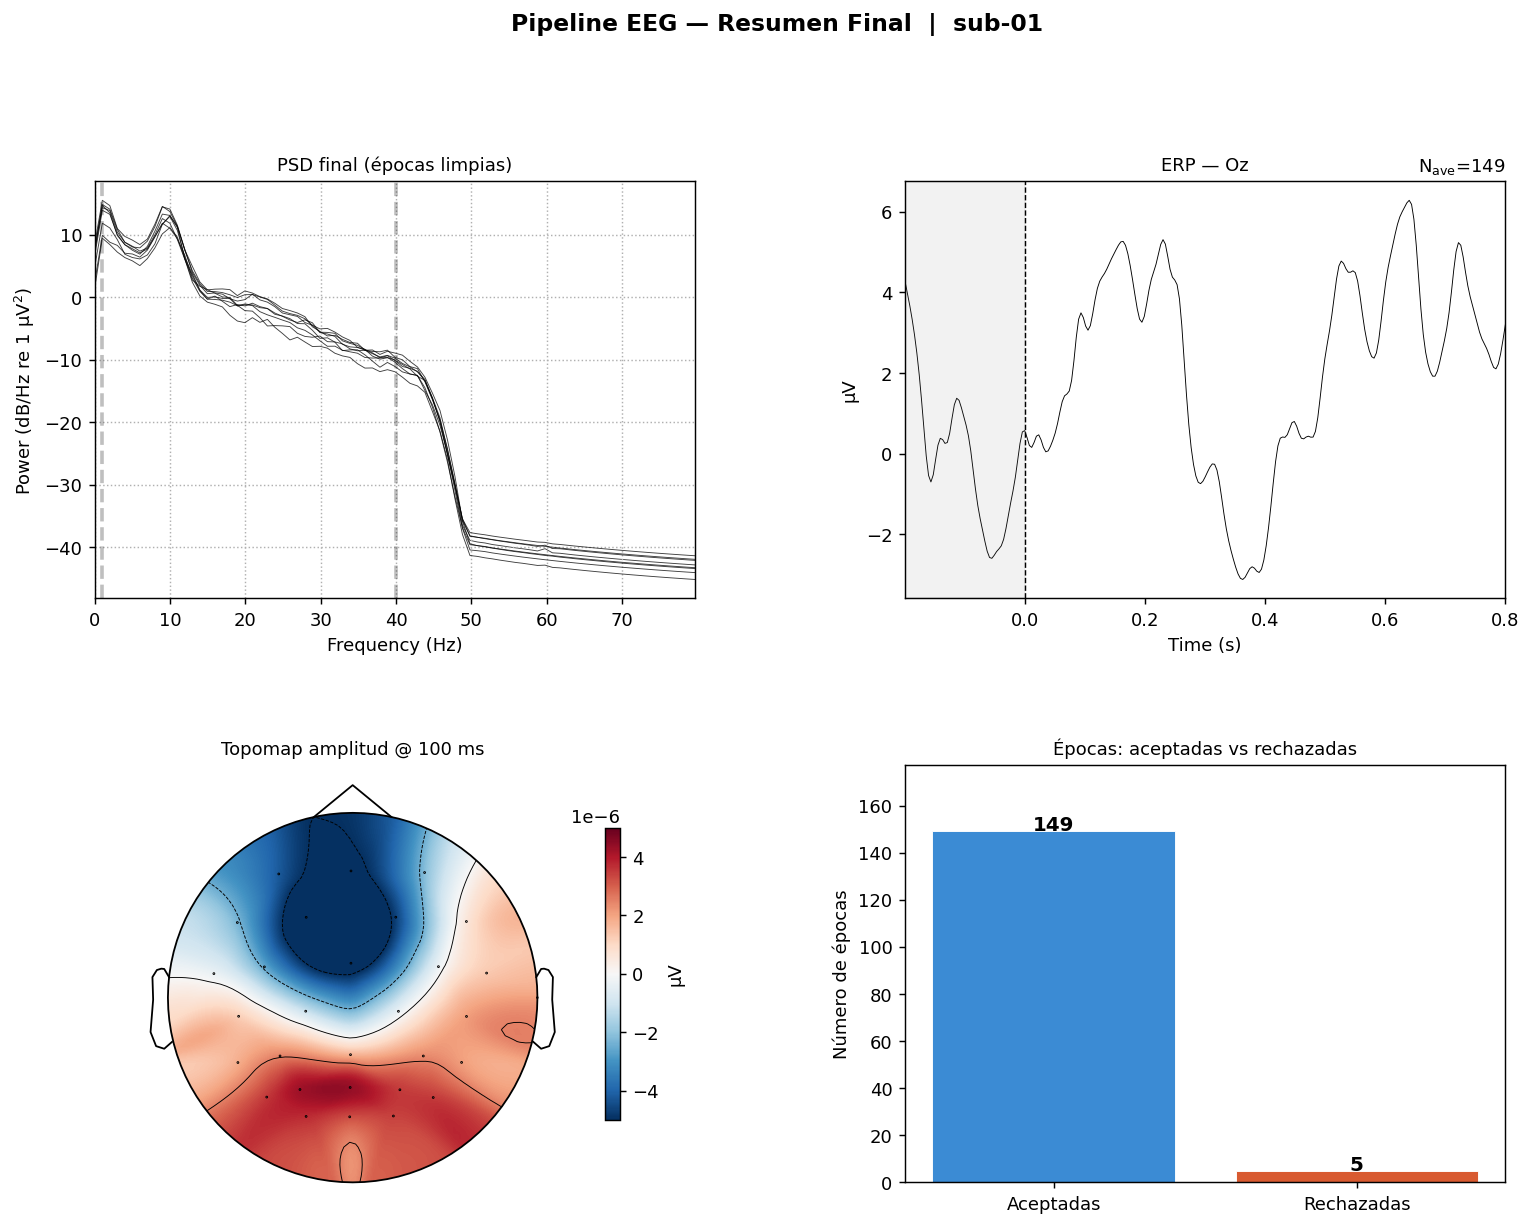


✅ ¡Pipeline completado! Los datos están listos para análisis.


In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  RESUMEN FINAL DEL PIPELINE
# ─────────────────────────────────────────────────────────────────────────────

print("=" * 60)
print("  RESUMEN DE PREPROCESAMIENTO EEG")
print("=" * 60)

stats = [
    ("Sujeto",                CONFIG["subject_id"]),
    ("Frecuencia de muestreo",f"{raw.info['sfreq']} Hz"),
    ("Canales EEG finales",   str(len(mne.pick_types(raw.info, eeg=True)))),
    ("Canales interpolados",  str(len(bad_channels_list))),
    ("Filtro pasa-altas",     f"{CONFIG['highpass_freq']} Hz"),
    ("Filtro pasa-bajas",     f"{CONFIG['lowpass_freq']} Hz"),
    ("Notch",                 f"{CONFIG['notch_freqs']} Hz"),
    ("Referencia",            str(CONFIG["reference"])),
    ("Método ICA",            f"{CONFIG['ica_method']} (extended={CONFIG['ica_extended']})"),
    ("Componentes ICA total", str(ica.n_components_)),
    ("Componentes rechazados",str(len(ica.exclude))),
    ("Épocas finales",        str(len(epochs))),
    ("Ventana temporal",      f"[{tmin}, {tmax}] s"),
    ("Línea base",            str(CONFIG["baseline"])),
]

for label, value in stats:
    print(f"  {label:<28}: {value}")

print("=" * 60)

# ── Figura resumen 2×2 ────────────────────────────────────────────────────────
fig = plt.figure(figsize=(14, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.35)

# Panel 1: PSD final
ax1  = fig.add_subplot(gs[0, 0])
# Recomputar picks válidos sobre el estado actual de epochs
eeg_picks_ep      = _valid_eeg_picks_epochs(epochs)
eeg_picks_ep_names = [epochs.ch_names[i] for i in eeg_picks_ep]
psd_ep = epochs.compute_psd(method="welch", fmax=80,
                              picks=eeg_picks_ep[:8], verbose=False)
psd_ep.plot(axes=ax1, show=False, spatial_colors=False)
ax1.set_title("PSD final (épocas limpias)", fontsize=10)

# Panel 2: ERP por canal Oz/Pz si existe
ax2 = fig.add_subplot(gs[0, 1])
target_chs = [ch for ch in ["Oz","Pz","Cz","P7","O1"] if ch in epochs.ch_names]
if target_chs:
    ev2 = epochs.average(picks=target_chs[:1])
    ev2.plot(axes=ax2, show=False, spatial_colors=False)
    ax2.set_title(f"ERP — {target_chs[0]}", fontsize=10)
    ax2.axvline(0, color="k", ls="--", lw=0.8)
    ax2.axvspan(CONFIG["baseline"][0], CONFIG["baseline"][1],
                alpha=0.1, color="gray")
else:
    evoked.plot(axes=ax2, show=False, gfp=True, spatial_colors=False)
    ax2.set_title("GFP (Global Field Power)", fontsize=10)

# Panel 3: Topomapa de la amplitud media ERP (N1 ~ 100 ms)
ax3 = fig.add_subplot(gs[1, 0])
evoked_all = epochs.average(picks=eeg_picks_ep)
try:
    t_idx = evoked_all.time_as_index(0.1)[0]
    im, _ = mne.viz.plot_topomap(
        evoked_all.data[:, t_idx], evoked_all.info,
        axes=ax3, show=False, contours=4,
        cmap="RdBu_r", vlim=(-5e-6, 5e-6)
    )
    ax3.set_title("Topomap amplitud @ 100 ms", fontsize=10)
    plt.colorbar(im, ax=ax3, shrink=0.7, label="µV")
except Exception as e:
    ax3.text(0.5, 0.5, f"Topomap\nno disponible\n{e}",
             ha="center", va="center", fontsize=8, transform=ax3.transAxes)
    ax3.set_title("Topomap amplitud @ 100 ms", fontsize=10)

# Panel 4: Histograma de épocas rechazadas
ax4 = fig.add_subplot(gs[1, 1])
n_final   = len(epochs)
n_initial = n_before
n_rej     = n_initial - n_final
bars      = ax4.bar(["Aceptadas", "Rechazadas"], [n_final, n_rej],
                     color=["#3B8BD4", "#D85A30"], edgecolor="white",
                     linewidth=0.5)
for bar, val in zip(bars, [n_final, n_rej]):
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             str(val), ha="center", fontsize=11, fontweight="bold")
ax4.set_title("Épocas: aceptadas vs rechazadas", fontsize=10)
ax4.set_ylabel("Número de épocas")
ax4.set_ylim(0, n_initial * 1.15)

fig.suptitle(f"Pipeline EEG — Resumen Final  |  {CONFIG['subject_id']}",
             fontsize=13, fontweight="bold", y=1.01)

summary_path = f"{CONFIG['output_dir']}/summary_final.png"
fig.savefig(summary_path, dpi=130, bbox_inches="tight")
plt.close()
display(Image(summary_path))
print("\n✅ ¡Pipeline completado! Los datos están listos para análisis.")

## 📥 Descargar archivos

Descarga los archivos preprocesados desde Colab a tu máquina local.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  DESCARGA DE ARCHIVOS DESDE COLAB
# ─────────────────────────────────────────────────────────────────────────────
from google.colab import files
import zipfile

out_dir = CONFIG["output_dir"]
sid     = CONFIG["subject_id"]

# Comprimir todos los archivos de salida
zip_path = f"/content/{sid}_preprocessed.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as zf:
    for fname in os.listdir(out_dir):
        fpath = os.path.join(out_dir, fname)
        if os.path.isfile(fpath):
            zf.write(fpath, fname)
            print(f"  + {fname}")

zip_size = os.path.getsize(zip_path) / 1e6
print(f"\nZIP creado: {os.path.basename(zip_path)}  ({zip_size:.1f} MB)")
print("Iniciando descarga...")

files.download(zip_path)

  + autoreject_log.png
  + psd_notch.png
  + psd_filtrada.png
  + sub-01_ica.fif
  + sub-01_post_interp_raw.fif
  + sub-01_preprocessed_raw.fif
  + sub-01_preprocessing_report.json
  + erp_global.png
  + montaje.png
  + sub-01_final-ica.fif
  + sub-01_preprocessed-epo.fif
  + bad_channels.png
  + summary_final.png

ZIP creado: sub-01_preprocessed.zip  (20.0 MB)
Iniciando descarga...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 🔁 Extra — Procesamiento por lotes (múltiples sujetos)

Equivalente al **EEGLAB STUDY batch processing**. Ejecuta el pipeline completo para una lista de archivos automáticamente.

In [ ]:
# ─────────────────────────────────────────────────────────────────────────────
#  PROCESAMIENTO POR LOTES — MÚLTIPLES SUJETOS
#  Equivalente a EEGLAB STUDY batch processing
# ─────────────────────────────────────────────────────────────────────────────

def preprocess_single_subject(filepath: str, subject_id: str, config: dict) -> dict:
    """
    Ejecuta el pipeline completo para un único sujeto.
    Retorna un reporte con estadísticas del procesamiento.
    """
    import copy
    cfg = copy.deepcopy(config)
    cfg["subject_id"] = subject_id
    cfg["output_dir"] = os.path.join(config["output_dir"], subject_id)
    os.makedirs(cfg["output_dir"], exist_ok=True)

    rep = {"subject_id": subject_id, "status": "unknown"}

    try:
        ext = Path(filepath).suffix.lower()
        loaders = {
            ".set":  lambda f: mne.io.read_raw_eeglab(f, preload=True, verbose=False),
            ".edf":  lambda f: mne.io.read_raw_edf(f, preload=True, verbose=False),
            ".bdf":  lambda f: mne.io.read_raw_bdf(f, preload=True, verbose=False),
            ".vhdr": lambda f: mne.io.read_raw_brainvision(f, preload=True, verbose=False),
            ".fif":  lambda f: mne.io.read_raw_fif(f, preload=True, verbose=False),
        }
        raw_s = loaders[ext](filepath)

        # Remuestreo
        if cfg["resample"] and raw_s.info["sfreq"] != cfg["sfreq_target"]:
            raw_s.resample(cfg["sfreq_target"], npad="auto", verbose=False)

        # Montaje
        try:
            mt = mne.channels.make_standard_montage(cfg["montage"])
            raw_s.set_montage(mt, on_missing="ignore", verbose=False)
        except Exception:
            pass

        # Filtrado
        eeg_p = mne.pick_types(raw_s.info, eeg=True, eog=False, stim=False)
        raw_s.filter(l_freq=cfg["highpass_freq"], h_freq=cfg["lowpass_freq"],
                     picks=eeg_p, method="fir", fir_window="hamming",
                     phase="zero", verbose=False)

        # Notch
        all_n = []
        for b in cfg["notch_freqs"]:
            h = b
            while h < raw_s.info["sfreq"] / 2:
                all_n.append(h); h += b
        raw_s.notch_filter(all_n, picks=eeg_p, method="fir",
                            phase="zero", verbose=False)

        # Re-referencia (MNE >= 1.2: sin argumento picks)
        raw_s.set_eeg_reference(ref_channels="average", projection=False,
                                verbose=False)

        # Canales malos
        data_uv = raw_s.get_data(picks=eeg_p) * 1e6
        rms = np.sqrt(np.mean(data_uv**2, axis=1))
        mad = np.median(np.abs(rms - np.median(rms)))
        z   = (rms - np.median(rms)) / (mad * 1.4826 + 1e-10)
        bads = list(np.array(raw_s.ch_names)[eeg_p][np.abs(z) > 3.0])
        stds = np.std(data_uv, axis=1)
        bads += list(np.array(raw_s.ch_names)[eeg_p][stds < 0.5])
        raw_s.info["bads"] = list(set(bads))
        if raw_s.info["bads"]:
            raw_s.interpolate_bads(reset_bads=True, verbose=False)

        # ICA
        # MNE >= 1.6: compute_rank sin 'picks' → copia EEG-only
        _raw_eeg = raw_s.copy().pick('eeg')
        rank_v   = list(mne.compute_rank(_raw_eeg, verbose=False).values())[0]
        del _raw_eeg
        n_comps = min(rank_v - 1, 25)
        ica_s   = ICA(n_components=n_comps, method=cfg["ica_method"],
                      fit_params={"extended": cfg["ica_extended"]},
                      max_iter=cfg["ica_max_iter"],
                      random_state=cfg["ica_random_state"], verbose=False)
        raw_filt = raw_s.copy().filter(1.0, None, picks=eeg_p,
                                        method="fir", phase="zero", verbose=False)
        ica_s.fit(raw_filt, picks=eeg_p, verbose=False)
        del raw_filt

        excl = []
        if ICALABEL_OK:
            ic_l = label_components(raw_s, ica_s, method="iclabel")
            for idx, (lbl, prb) in enumerate(zip(ic_l["labels"], ic_l["y_pred_proba"])):
                if lbl in cfg["ica_reject_labels"] and max(prb) >= cfg["ica_threshold"]:
                    excl.append(idx)
        ica_s.exclude = excl
        ica_s.apply(raw_s, verbose=False)

        # Épocas
        try:
            evts, eid = mne.events_from_annotations(raw_s, verbose=False)
        except Exception:
            evts = mne.make_fixed_length_events(raw_s,
                       duration=cfg["tmax"] - cfg["tmin"], id=1)
            eid  = {"epoch": 1}

        ep_s = Epochs(raw_s, evts, eid, tmin=cfg["tmin"], tmax=cfg["tmax"],
                      baseline=None, preload=True, verbose=False)

        if AUTOREJECT_OK:
            _vp = [i for i in mne.pick_types(ep_s.info, eeg=True)
                   if np.all(np.isfinite(ep_s.info["chs"][i]["loc"][:3]))
                   and not np.all(ep_s.info["chs"][i]["loc"][:3] == 0)]
            ar_s = AutoReject(picks=_vp, random_state=42,
                              n_jobs=1, verbose=False)
            ep_s, _ = ar_s.fit_transform(ep_s, return_log=True)
        else:
            ep_s.drop_bad(reject={"eeg": 100e-6}, verbose=False)

        ep_s.apply_baseline(cfg["baseline"], verbose=False)

        # Guardar
        ep_path = os.path.join(cfg["output_dir"], f"{subject_id}_preprocessed-epo.fif")
        ep_s.save(ep_path, overwrite=cfg["overwrite"], verbose=False)

        rep.update({
            "status": "✅ OK",
            "n_epochs": len(ep_s),
            "n_ica_excluded": len(excl),
            "bad_channels": bads,
            "output": ep_path,
        })

    except Exception as e:
        rep.update({"status": f"❌ ERROR: {e}"})
        print(f"  ERROR en {subject_id}: {e}")

    return rep


# ─────────────────────────────────────────────────────────────────────────────
#  EJEMPLO DE USO — descomenta y modifica según tus archivos
# ─────────────────────────────────────────────────────────────────────────────

# file_list = [
#     "/content/sub-01.set",
#     "/content/sub-02.set",
#     "/content/sub-03.set",
# ]
# subject_ids = ["sub-01", "sub-02", "sub-03"]

# all_reports = []
# for fpath, sid in zip(file_list, subject_ids):
#     print(f"\nProcesando: {sid}")
#     r = preprocess_single_subject(fpath, sid, CONFIG)
#     all_reports.append(r)
#     print(f"  {r['status']} — {r.get('n_epochs','?')} épocas")

# print("\n" + "="*60)
# print(pd.DataFrame(all_reports).to_string(index=False))

print("✅ Función batch lista.")
print("   Descomenta las últimas líneas y modifica las rutas para usar.")

✅ Función batch lista.
   Descomenta las últimas líneas y modifica las rutas para usar.
